# Bài tập 4 – Gom cụm (Clustering)

**Dữ liệu**: Instacart Market Basket Analysis 
---


## [01] Load dữ liệu đã xử lý từ Bài 1

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import silhouette_score, davies_bouldin_score
from IPython.display import display

DATA_PATH = '../../data/processed/D2_instacart/customer_features.csv'

df_raw = pd.read_csv(DATA_PATH)

print(f"Kích thước dữ liệu: {df_raw.shape}")
display(df_raw.head())

Kích thước dữ liệu: (18047, 6)


,user_id,orders,products,unique_products,reorder_rate,mean_cart_position
0,13,1,5,5,0.600000,3.0
1,23,1,9,9,0.000000,5.0
2,27,1,13,13,0.461538,7.0
3,36,1,3,3,0.333333,2.0
4,42,1,6,6,0.166667,3.5


## [02] Feature Selection

Đơn vị quan sát của bài toán là khách hàng (`user_id`).

Các đặc trưng được sử dụng để gom cụm phản ánh hành vi mua sắm của khách hàng:

- `orders`: số đơn hàng.
- `products`: tổng số sản phẩm đã mua.
- `unique_products`: số sản phẩm khác nhau.
- `reorder_rate`: tỷ lệ sản phẩm được mua lại.
- `mean_cart_position`: vị trí trung bình khi sản phẩm được thêm vào giỏ.

Không sử dụng `user_id` làm đặc trưng vì đây là thuộc tính định danh, không mang ý nghĩa về khoảng cách giữa các khách hàng.

In [2]:
df = df_raw.copy()

DROP_COLS = ['user_id', 'cluster']

df = df.drop(
    columns=[c for c in DROP_COLS if c in df.columns]
)

NUM_COLS = [
    'orders',
    'products',
    'unique_products',
    'reorder_rate',
    'mean_cart_position'
]

print("Các đặc trưng sử dụng:")
print(NUM_COLS)

Các đặc trưng sử dụng:
['orders', 'products', 'unique_products', 'reorder_rate', 'mean_cart_position']


## [03] Kiểm tra và xử lý biến categorical
Tất cả các đặc trưng trong bộ D2 sau tiền xử lý Bài 1 đều là dạng số, không có biến categorical cần mã hóa thêm.

Kiểm tra lại để đảm bảo không còn giá trị object hay giá trị thiếu.


In [3]:
df_enc = df[NUM_COLS].copy()

# Xử lý giá trị thiếu nếu có (fillna = 0)
df_enc = df_enc.fillna(0)

print("Các cột dạng object còn lại:", df_enc.select_dtypes(include='object').columns.tolist())
print("Giá trị thiếu:", df_enc.isna().sum().sum())
print("df_enc:", df_enc.shape)

Các cột dạng object còn lại: []
Giá trị thiếu: 0
df_enc: (18047, 5)


## [04] Scaling (Chuẩn hoá) 🔴

**Tại sao bắt buộc?**  
K-Means và Agglomerative dựa trên **khoảng cách Euclidean**.  
Nếu không chuẩn hoá, đặc trưng có phạm vi lớn (ví dụ `products` hàng trăm sản phẩm)  
sẽ áp đảo đặc trưng có phạm vi nhỏ (ví dụ `reorder_rate` 0–1), làm sai lệch phân cụm.

**Phương pháp**: `StandardScaler` → mỗi đặc trưng có mean=0, std=1.


In [4]:
# [04] Scaling
scaler = StandardScaler()

df_scaled = pd.DataFrame(
    scaler.fit_transform(df_enc),
    columns=df_enc.columns,
    index=df_enc.index
)

# Kết quả sau scaling
print("KẾT QUẢ SAU SCALING:")
display(
    df_scaled.describe()
    .loc[['mean', 'std']]
    .round(2)
)

KẾT QUẢ SAU SCALING:


,orders,products,unique_products,reorder_rate,mean_cart_position
mean,-0.0,0.0,-0.0,0.0,0.0
std,1.0,1.0,1.0,1.0,1.0


## [05] Tạo X cuối cùng
 Gom phần dữ liệu đó thành ma trận X, để đưa trực tiếp vào các thuật toán clustering

In [5]:
# Ma trận đặc trưng cuối cùng
X = df_scaled.values

print(f"X.shape = {X.shape} → {X.shape[0]} mẫu, {X.shape[1]} đặc trưng")

X.shape = (18047, 5) → 18047 mẫu, 5 đặc trưng


## [06] Thuật toán K-Means

**Giả định**:
- Các cụm có dạng hình cầu, kích thước tương đương
- Khoảng cách Euclidean là thước đo phù hợp
- Số cụm K phải được chỉ định trước

**Cơ chế**: Lặp gán điểm vào centroid gần nhất → cập nhật centroid → hội tụ khi centroid không đổi.


In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import numpy as np

K_RANGE = range(2, 11)

inertias = []
sil_scores = []

np.random.seed(42)
sample_size = min(15000, X.shape[0])
sample_idx = np.random.choice(
    X.shape[0],
    size=sample_size,
    replace=False
)

X_sample = X[sample_idx]

for k in K_RANGE:

    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    km.fit(X)

    inertias.append(km.inertia_)

    # Chỉ tính Silhouette trên mẫu
    sil = silhouette_score(
        X_sample,
        km.labels_[sample_idx]
    )

    sil_scores.append(sil)

    print(f"K={k} hoàn thành")

print("\nk | Inertia       | Silhouette")
print("-" * 35)

for k, ine, sil in zip(K_RANGE, inertias, sil_scores):
    print(f"{k:2d} | {ine:12.1f} | {sil:.4f}")

K=2 hoàn thành
K=3 hoàn thành
K=4 hoàn thành
K=5 hoàn thành
K=6 hoàn thành
K=7 hoàn thành
K=8 hoàn thành
K=9 hoàn thành
K=10 hoàn thành

k | Inertia       | Silhouette
-----------------------------------
 2 |      56507.1 | 0.4505
 3 |      43871.5 | 0.4265
 4 |      32969.5 | 0.3919
 5 |      25475.1 | 0.4113
 6 |      21319.0 | 0.4126
 7 |      18678.6 | 0.4016
 8 |      16516.0 | 0.3909
 9 |      14756.7 | 0.3913
10 |      13224.5 | 0.3970


## [07] Silhouette → Chọn K 🔴
**Silhouette Score**: Đo mức độ điểm thuộc cụm của nó so với cụm kế cận (1 = tốt, -1 = xấu).  
→ Chọn K có silhouette cao nhất hoặc thoả điểm elbow.


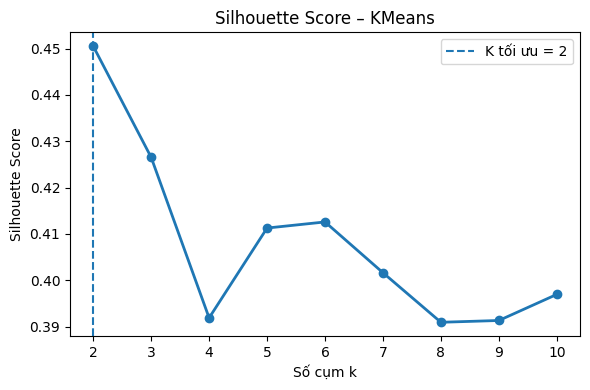

→ Chọn K = 2 (Silhouette = 0.4505)
KMeans k=2: Silhouette=0.4505, Davies-Bouldin=1.0700


In [7]:
# =========================
# Silhouette → Chọn K
# =========================

plt.figure(figsize=(6, 4))

plt.plot(
    list(K_RANGE),
    sil_scores,
    'o-',
    linewidth=2
)

best_k = list(K_RANGE)[int(np.argmax(sil_scores))]

plt.axvline(
    best_k,
    linestyle='--',
    label=f'K tối ưu = {best_k}'
)

plt.title('Silhouette Score – KMeans')
plt.xlabel('Số cụm k')
plt.ylabel('Silhouette Score')
plt.xticks(list(K_RANGE))
plt.legend()
plt.tight_layout()
plt.show()

print(f"→ Chọn K = {best_k} "
      f"(Silhouette = {max(sil_scores):.4f})")


# =========================
# KMeans với K tối ưu
# =========================

kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

km_labels = kmeans.fit_predict(X)

sil_km = silhouette_score(
    X_sample,
    km_labels[sample_idx]
)

db_km = davies_bouldin_score(
    X_sample,
    km_labels[sample_idx]
)

print(
    f"KMeans k={best_k}: "
    f"Silhouette={sil_km:.4f}, "
    f"Davies-Bouldin={db_km:.4f}"
)

## [08] Thuật toán DBSCAN

**Giả định**:
Hai tham số chính của DBSCAN:

- `eps`: bán kính lân cận của một điểm.
- `min_samples`: số điểm tối thiểu trong vùng lân cận `eps` để xác định một điểm là điểm lõi (core point).

**Cơ chế**:
DBSCAN phân loại các điểm thành:
- Core point: có ít nhất `min_samples` điểm trong bán kính `eps`.
- Border point: không phải core point nhưng nằm trong vùng lân cận của core point.
- Noise point: không thuộc vùng của các điểm lõi.


DBSCAN không yêu cầu xác định trước số cụm và có khả năng phát hiện
các điểm nhiễu.

Do DBSCAN sử dụng khoảng cách Euclidean, dữ liệu được chuẩn hóa trước
khi phân cụm để hạn chế ảnh hưởng của sự khác biệt về thang đo giữa
các đặc trưng.

In [8]:
#chọn min_samples
D = X.shape[1]
min_pts = 2 * D

print(f"Số đặc trưng D = {D}")
print(f"min_samples = {min_pts}")

Số đặc trưng D = 5
min_samples = 10


Với dữ liệu D2 sau tiền xử lý có 5 đặc trưng, chọn ban đầu
`min_samples = 2 × D = 10` theo quy tắc kinh nghiệm.

Giá trị này được giữ cố định trong quá trình khảo sát và lựa chọn
`eps` ở các bước tiếp theo.

 8.1. Xác định vùng `eps` bằng K-distance Graph

Để lựa chọn `eps`, sử dụng K-distance Graph. Với mỗi điểm dữ liệu,
tính khoảng cách đến láng giềng thứ `min_samples`, sau đó sắp xếp
các khoảng cách theo thứ tự tăng dần.

Vùng mà đường cong bắt đầu tăng mạnh được xem là vùng giá trị
`eps` ứng viên.

Do dữ liệu có thể lớn, sử dụng một mẫu ngẫu nhiên tối đa 15.000 dòng
để giảm chi phí tính toán khi xây dựng K-distance Graph.

Số đặc trưng D = 5
min_samples = 10

Các percentile của khoảng cách:
90% percentile: 0.2102
92% percentile: 0.2338
94% percentile: 0.2759
95% percentile: 0.3140
96% percentile: 0.3616
97% percentile: 0.4242
98% percentile: 0.5312
99% percentile: 0.7614
99.5% percentile: 1.0776
99.9% percentile: 3.1422


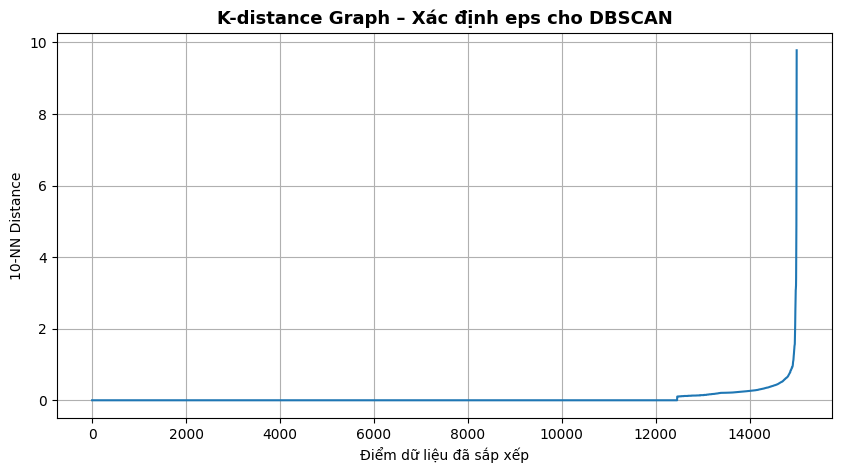

In [9]:
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt
import numpy as np

np.random.seed(42)

sample_size_dbscan = min(15000, X.shape[0])
sample_idx = np.random.choice(
    X.shape[0],
    size=sample_size_dbscan,
    replace=False
)

X_sample = X[sample_idx]

# Tính min_samples
# Quy tắc kinh nghiệm: min_samples = 2 × D
min_pts = X.shape[1] * 2

print(f"Số đặc trưng D = {X.shape[1]}")
print(f"min_samples = {min_pts}")

# Tìm k-distance trên X_sample
neighbors = NearestNeighbors(
    n_neighbors=min_pts,
    n_jobs=-1
)

neighbors_fit = neighbors.fit(X_sample)

distances, indices = neighbors_fit.kneighbors(X_sample)

# Lấy khoảng cách đến hàng xóm thứ min_samples
distances = np.sort(
    distances[:, min_pts - 1],
    axis=0
)

# ==============================
# XEM CÁC PERCENTILE
# ==============================
print("\nCác percentile của khoảng cách:")

for p in [90, 92, 94, 95, 96, 97, 98, 99, 99.5, 99.9]:
    print(
        f"{p}% percentile: "
        f"{np.percentile(distances, p):.4f}"
    )

# ==============================
# VẼ K-DISTANCE GRAPH
# ==============================
plt.figure(figsize=(10, 5))

plt.plot(distances)

plt.title(
    'K-distance Graph – Xác định eps cho DBSCAN',
    fontsize=13,
    fontweight='bold'
)

plt.xlabel('Điểm dữ liệu đã sắp xếp')
plt.ylabel(f'{min_pts}-NN Distance')

plt.grid(True)
plt.show()

### 8.3. Nhận xét

Kết quả cho thấy dữ liệu D2 có 5 đặc trưng, do đó `min_samples` được
khởi tạo bằng `2 × D = 10` theo quy tắc kinh nghiệm.

Từ K-distance Graph và các percentile của khoảng cách, xác định vùng
giá trị `eps` ứng viên dựa trên vị trí đường cong bắt đầu tăng mạnh.

Các giá trị `eps` ứng viên sẽ được chạy và đánh giá ở bước [10] dựa
trên số cụm, tỷ lệ điểm nhiễu, Silhouette Score và Davies-Bouldin Index.

## [9] Thử nghiệm các giá trị `eps` – DBSCAN

Từ K-distance Graph ở bước [08], xác định vùng `eps` ứng viên phù hợp.

Thay vì chọn một giá trị `eps` duy nhất chỉ dựa trên đồ thị,
tiến hành thử nghiệm một dải các giá trị trong vùng ứng viên.

Trong quá trình thử nghiệm, giữ cố định `min_samples = 2 × D` để
đánh giá riêng ảnh hưởng của `eps`.

Mỗi cấu hình được ghi nhận:
- Số cụm được tạo ra.
- Số lượng điểm nhiễu (noise).
- Tỷ lệ điểm nhiễu.

Các kết quả này sẽ được sử dụng ở bước tiếp theo để đánh giá
chất lượng phân cụm bằng Silhouette Score và Davies-Bouldin Index.

In [10]:
from sklearn.cluster import DBSCAN
import numpy as np

# Điều chỉnh EPS_RANGE dựa trên K-distance Graph ở bước trên
EPS_RANGE = [0.3, 0.5, 0.7, 1.0, 1.5, 2.0, 2.5]

print(f"Kích thước dữ liệu: {X_sample.shape}")
print(f"min_samples = {min_pts}")

results_dbscan = []

for eps in EPS_RANGE:
    print(f"\nĐang chạy DBSCAN với eps = {eps}...")

    dbscan = DBSCAN(
        eps=eps,
        min_samples=min_pts,
        metric='euclidean',
        n_jobs=-1
    )

    labels = dbscan.fit_predict(X_sample)

    # Số cụm, không tính noise (-1)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

    # Số điểm noise
    n_noise = np.sum(labels == -1)

    # Tỷ lệ noise
    noise_ratio = n_noise / len(labels) * 100

    results_dbscan.append({
        'eps': eps,
        'min_samples': min_pts,
        'n_clusters': n_clusters,
        'n_noise': n_noise,
        'noise_ratio': noise_ratio
    })

    print(f"Số cụm: {n_clusters}")
    print(f"Noise: {n_noise}")
    print(f"Tỷ lệ noise: {noise_ratio:.2f}%")

Kích thước dữ liệu: (15000, 5)
min_samples = 10

Đang chạy DBSCAN với eps = 0.3...
Số cụm: 11
Noise: 567
Tỷ lệ noise: 3.78%

Đang chạy DBSCAN với eps = 0.5...
Số cụm: 5
Noise: 215
Tỷ lệ noise: 1.43%

Đang chạy DBSCAN với eps = 0.7...
Số cụm: 5
Noise: 104
Tỷ lệ noise: 0.69%

Đang chạy DBSCAN với eps = 1.0...
Số cụm: 3
Noise: 58
Tỷ lệ noise: 0.39%

Đang chạy DBSCAN với eps = 1.5...
Số cụm: 3
Noise: 32
Tỷ lệ noise: 0.21%

Đang chạy DBSCAN với eps = 2.0...
Số cụm: 3
Noise: 26
Tỷ lệ noise: 0.17%

Đang chạy DBSCAN với eps = 2.5...
Số cụm: 3
Noise: 22
Tỷ lệ noise: 0.15%


KẾT QUẢ

In [11]:
df_dbscan_results = pd.DataFrame(results_dbscan)

display(
    df_dbscan_results[
        ['eps', 'min_samples', 'n_clusters', 'n_noise', 'noise_ratio']
    ]
)

,eps,min_samples,n_clusters,n_noise,noise_ratio
0,0.3,10,11,567,3.780000
1,0.5,10,5,215,1.433333
2,0.7,10,5,104,0.693333
3,1.0,10,3,58,0.386667
4,1.5,10,3,32,0.213333
5,2.0,10,3,26,0.173333
6,2.5,10,3,22,0.146667


## [10] Đánh giá: Silhouette + Davies-Bouldin 🔴

Đánh giá các cấu hình DBSCAN đã thử nghiệm ở bước [09] bằng
Silhouette Score và Davies-Bouldin Index.

- Silhouette Score: càng cao càng tốt, phản ánh mức độ phân tách
  và độ gắn kết của các cụm.
- Davies-Bouldin Index: càng thấp càng tốt, phản ánh mức độ
  tương đồng giữa các cụm.

Đối với DBSCAN, các điểm nhiễu (`label = -1`) được loại khỏi quá trình
tính hai chỉ số này để đánh giá chất lượng phân tách của các điểm
đã được gán vào cụm.

Kết quả được sử dụng để lựa chọn cấu hình `eps` phù hợp.

In [12]:
from sklearn.metrics import silhouette_score, davies_bouldin_score
import pandas as pd
import numpy as np
from sklearn.cluster import DBSCAN

evaluation_results = []

for eps in EPS_RANGE:
    print(f"Đang đánh giá eps = {eps}...")

    dbscan = DBSCAN(
        eps=eps,
        min_samples=min_pts,
        metric='euclidean',
        n_jobs=-1
    )

    labels = dbscan.fit_predict(X_sample)

    # Bỏ các điểm nhiễu
    mask = labels != -1
    X_eval = X_sample[mask]
    labels_eval = labels[mask]

    n_clusters = len(np.unique(labels_eval))

    if n_clusters >= 2:
        sil = silhouette_score(X_eval, labels_eval)
        dbi = davies_bouldin_score(X_eval, labels_eval)
    else:
        sil = np.nan
        dbi = np.nan

    n_noise = np.sum(labels == -1)
    noise_ratio = n_noise / len(labels) * 100

    evaluation_results.append({
        'eps': eps,
        'n_clusters': n_clusters,
        'noise_ratio': noise_ratio,
        'silhouette': sil,
        'davies_bouldin': dbi
    })

df_eval = pd.DataFrame(evaluation_results)

display(df_eval)

Đang đánh giá eps = 0.3...
Đang đánh giá eps = 0.5...
Đang đánh giá eps = 0.7...
Đang đánh giá eps = 1.0...
Đang đánh giá eps = 1.5...
Đang đánh giá eps = 2.0...
Đang đánh giá eps = 2.5...


,eps,n_clusters,noise_ratio,silhouette,davies_bouldin
0,0.3,11,3.780000,-0.179430,0.739935
1,0.5,5,1.433333,0.442263,0.710219
2,0.7,5,0.693333,0.457402,0.813943
3,1.0,3,0.386667,0.467251,1.078613
4,1.5,3,0.213333,0.472109,1.135064
5,2.0,3,0.173333,0.472549,1.143129
6,2.5,3,0.146667,0.472259,1.156976


## [11] So sánh K-Means và DBSCAN 🔴

Sau khi lựa chọn cấu hình cho từng thuật toán, tiến hành tổng hợp và
so sánh kết quả của K-Means và DBSCAN.

Các tiêu chí so sánh gồm:

- Số lượng cụm.
- Silhouette Score: càng cao càng tốt.
- Davies-Bouldin Index: càng thấp càng tốt.
- Tỷ lệ điểm nhiễu đối với DBSCAN.

K-Means sử dụng cấu hình `K` đã được lựa chọn ở bước [07].
DBSCAN sử dụng cấu hình `eps` được lựa chọn ở bước [10].

In [13]:
# Chọn eps tốt nhất dựa trên Silhouette Score cao nhất
# (lọc ra các hàng có ít nhất 2 cụm và Silhouette không phải NaN)
df_eval_valid = df_eval.dropna(subset=['silhouette'])
if len(df_eval_valid) > 0:
    eps_opt = df_eval_valid.loc[df_eval_valid['silhouette'].idxmax(), 'eps']
else:
    eps_opt = EPS_RANGE[len(EPS_RANGE) // 2]  # fallback: giá trị giữa

dbscan_best = df_eval[
    df_eval['eps'] == eps_opt
].iloc[0]

n_clusters_db = dbscan_best['n_clusters']
sil_db = dbscan_best['silhouette']
db_db = dbscan_best['davies_bouldin']
noise_ratio_db = dbscan_best['noise_ratio']

print(f"eps được chọn: {eps_opt}")
print(f"Số cụm DBSCAN: {n_clusters_db}")
print(f"Silhouette: {sil_db:.4f}")
print(f"Davies-Bouldin: {db_db:.4f}")
print(f"Noise ratio: {noise_ratio_db:.2f}%")

eps được chọn: 2.0
Số cụm DBSCAN: 3.0
Silhouette: 0.4725
Davies-Bouldin: 1.1431
Noise ratio: 0.17%


DBSCAN cuối cùng

In [14]:
# DBSCAN cuối cùng với cấu hình đã chọn
dbscan_final = DBSCAN(
    eps=eps_opt,
    min_samples=min_pts,
    metric='euclidean',
    n_jobs=-1
)

sample_labels = dbscan_final.fit_predict(X_sample)

print(f"DBSCAN final: eps={eps_opt}, min_samples={min_pts}")
print(f"Số cụm: {len(set(sample_labels)) - (1 if -1 in sample_labels else 0)}")
print(f"Số noise: {(sample_labels == -1).sum()}")

DBSCAN final: eps=2.0, min_samples=10
Số cụm: 3
Số noise: 26


Bảng so sánh

In [15]:
from IPython.display import display
comparison = pd.DataFrame({
    'Thuật toán': [
        'K-Means',
        'DBSCAN'
    ],

    'Cấu hình': [
        f'K = {best_k}',
        f'eps = {eps_opt}, min_samples = {min_pts}'
    ],

    'Số cụm': [
        best_k,
        n_clusters_db
    ],

    'Silhouette': [
        sil_km,
        sil_db
    ],

    'Davies-Bouldin': [
        db_km,
        db_db
    ],

    'Tỷ lệ noise (%)': [
        0,
        noise_ratio_db
    ]
})

display(comparison)

,Thuật toán,Cấu hình,Số cụm,Silhouette,Davies-Bouldin,Tỷ lệ noise (%)
0,K-Means,K = 2,2.0,0.450513,1.070011,0.000000
1,DBSCAN,"eps = 2.0, min_samples = 10",3.0,0.472549,1.143129,0.173333


### 11.1. Nhận xét so sánh

So sánh K-Means và DBSCAN trên bộ dữ liệu D2 (Instacart) theo các chỉ số:

- **Silhouette Score**: Thuật toán có Silhouette cao hơn cho thấy các điểm
  trong cùng cụm gần nhau hơn và các cụm tách biệt tốt hơn.

- **Davies-Bouldin Index**: Thuật toán có Davies-Bouldin thấp hơn cho thấy
  các cụm gọn và tách biệt tốt hơn.

DBSCAN có ưu điểm là không cần xác định trước số cụm và có khả năng
phát hiện điểm nhiễu trong dữ liệu.

Dựa trên kết quả đánh giá, thuật toán và cấu hình tốt hơn được chọn
làm kết quả clustering cuối cùng.

## [12] Cluster Profiling 

Mô tả đặc trưng nổi bật của từng cụm dựa trên giá trị trung bình các đặc trưng số.


[12.1] Kích thước các cụm

In [16]:
# Kích thước và tỷ lệ của từng cluster
cluster_size = (
    pd.Series(sample_labels)
    .value_counts()
    .sort_index()
    .rename_axis('cluster')
    .reset_index(name='count')
)

cluster_size['percentage'] = (
    cluster_size['count'] / len(sample_labels) * 100
).round(2)

display(cluster_size)

,cluster,count,percentage
0,-1,26,0.17
1,0,13633,90.89
2,1,1246,8.31
3,2,95,0.63


[12.2] Đặc trưng số của từng cụm

In [17]:
# Các biến số dùng để mô tả đặc trưng của cluster
profile_cols = NUM_COLS

df_profile = df_enc.iloc[sample_idx].copy()
df_profile['cluster'] = sample_labels

numeric_profile = (
    df_profile[df_profile['cluster'] != -1]
    .groupby('cluster')[profile_cols]
    .mean()
    .round(2)
)

display(numeric_profile)

,orders,products,unique_products,reorder_rate,mean_cart_position
cluster,,,,,
0,1.0,10.03,10.03,0.58,5.51
1,2.0,20.22,19.08,0.67,6.12
2,3.0,25.69,23.26,0.75,5.50


[12.4] Nhận xét Cluster Profiling

Kết quả profiling cho thấy các cluster có sự khác biệt về kích thước
và đặc trưng hành vi mua sắm trong không gian dữ liệu đã tiền xử lý.

Dựa trên các đặc trưng `orders`, `products`, `unique_products`,
`reorder_rate`, `mean_cart_position`, mỗi cụm đại diện cho
một nhóm khách hàng có hành vi mua sắm khác nhau:

- Khách hàng mua nhiều lần, nhiều sản phẩm đa dạng.
- Khách hàng mua ít lần, tập trung vào một số sản phẩm quen thuộc.
- Các điểm nhiễu (noise) đại diện cho hành vi bất thường hoặc không phổ biến.

DBSCAN có khả năng nhận diện các điểm nhiễu, phù hợp với
dữ liệu thương mại điện tử có nhiều outlier hành vi.